In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TRIK AMPUH: Otomatis deteksi folder tempat script ini berada
buku_lokasi = os.path.dirname(os.path.abspath(__file__))
nama_file_csv = "climatology_daily_2015-2025.csv"

# Gabungkan folder dan nama file
path_lengkap = os.path.join(buku_lokasi, nama_file_csv)

# Load data menggunakan path lengkap
df = pd.read_csv(path_lengkap, index_col="Date", parse_dates=True)

print("--- DATA BERHASIL DI-LOAD ---")
print(df.head())

# (Gunakan kode load file yang udah sukses tadi)
df = pd.read_csv("climatology_daily_2015-2025.csv", index_col="Date", parse_dates=True)

# =========================================================
#  PROSES MEMBUAT CLIMATE PROFILE
# =========================================================

# 1. Definisi Hari Hujan (Standard BMKG: Curah hujan >= 1 mm)
df['Hari_Hujan'] = df['PRECTOTCORR'] >= 1.0

print("\n=============================================")
print("  PROFIL IKLIM TAHUNAN (2015 - 2025)")
print("=============================================")

# Grouping data per tahun untuk dapet rata-rata & total
profil_tahunan = df.groupby(df.index.year).agg(
    Rata_Suhu_Tahunan=('T2M', 'mean'),
    Total_Hujan_Tahunan=('PRECTOTCORR', 'sum'),
    Rata_Kelembapan_Tahunan=('RH2M', 'mean'),
    Total_Hari_Hujan=('Hari_Hujan', 'sum')
)

# Tampilkan tabel tahunan (dibulatkan 2 angka di belakang koma)
print(profil_tahunan.round(2).to_string())


print("\n=============================================")
print("  REKOR BULANAN EKSTREM (ALL-TIME)")
print("=============================================")

# Resample data ke bulanan dulu
df_bulanan_mean = df.resample('ME').mean()
df_bulanan_sum = df.resample('ME').sum()

# A. Bulan Terpanas (Suhu rata-rata bulanan tertinggi)
idx_panas = df_bulanan_mean['T2M'].idxmax()
suhu_panas = df_bulanan_mean['T2M'].max()

# B. Bulan Terbasah (Total curah hujan bulanan tertinggi)
idx_basah = df_bulanan_sum['PRECTOTCORR'].idxmax()
hujan_basah = df_bulanan_sum['PRECTOTCORR'].max()

# C. Bulan Terkering (Total curah hujan bulanan terendah)
idx_kering = df_bulanan_sum['PRECTOTCORR'].idxmin()
hujan_kering = df_bulanan_sum['PRECTOTCORR'].min()

print(f"🔥 Bulan Terpanas : {idx_panas.strftime('%B %Y')} (Rata-rata Suhu: {suhu_panas:.2f}°C)")
print(f"🌧️ Bulan Terbasah : {idx_basah.strftime('%B %Y')} (Total Hujan: {hujan_basah:.2f} mm)")
print(f"🌵 Bulan Terkering: {idx_kering.strftime('%B %Y')} (Total Hujan: {hujan_kering:.2f} mm)")


print("\n=============================================")
print("  RATA-RATA JUMLAH HARI HUJAN PER BULAN")
print("=============================================")

# Hitung total hari hujan per bulan-tahun dulu
hari_hujan_per_bulan = df.groupby([df.index.year, df.index.month])['Hari_Hujan'].sum()

# Cari rata-ratanya berdasarkan kalender bulan (Januari-Desember) sepanjang rentang tahun
rata_hari_hujan = hari_hujan_per_bulan.groupby(level=1).mean()

nama_bulan = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
              'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']

for i, bln in enumerate(nama_bulan):
    print(f"- {bln.ljust(10)}: Rata-rata {rata_hari_hujan.iloc[i]:.1f} Hari Hujan")

# ==========================================
# 1. SETUP: DETEKSI FOLDER & LOAD DATA
# ==========================================
df = pd.read_csv("climatology_daily_2015-2025.csv", index_col="Date", parse_dates=True)

print("⏳ Sedang meload data harian...")
df = pd.read_csv(path_lengkap, index_col="Date", parse_dates=True)

# ==========================================
# 2. PROSES: CONVERT KE BULANAN & TAHUNAN
# ==========================================
print("⚙️ Memproses data bulanan dan tahunan...")

# Bikin Data Bulanan (Monthly)
df_monthly = pd.DataFrame()
df_monthly["T2M_mean"] = df["T2M"].resample("ME").mean()
df_monthly["RH2M_mean"] = df["RH2M"].resample("ME").mean()
df_monthly["RAIN_total"] = df["PRECTOTCORR"].resample("ME").sum()
df_monthly["RAIN_days"] = (df["PRECTOTCORR"] >= 1).resample("ME").sum()

# Bikin Data Tahunan (Yearly)
df_yearly = pd.DataFrame()
df_yearly["T2M_mean"] = df["T2M"].resample("YE").mean()
df_yearly["RH2M_mean"] = df["RH2M"].resample("YE").mean()
df_yearly["RAIN_total"] = df["PRECTOTCORR"].resample("YE").sum()
df_yearly["RAIN_days"] = (df["PRECTOTCORR"] >= 1).resample("YE").sum()

# ==========================================
# 3. EXPORT: SIMPAN JADI CSV BARU
# ==========================================
path_monthly = "hasil_bulanan_2015-2025.csv"
path_yearly = "hasil_tahunan_2015-2025.csv"

# Perintah ini yang bikin file Excel/CSV baru di foldermu!
df_monthly.to_csv(path_monthly)
df_yearly.to_csv(path_yearly)

print("\n✅ SUKSES! File baru berhasil dibuat di foldermu:")
print(f"👉 {path_monthly}")
print(f"👉 {path_yearly}")

# ==========================================
# 4. VISUALISASI: MUNCULKAN GRAFIK BULANAN
# ==========================================
# Kita plot Total Curah Hujan Bulanan (RAIN_total)
plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly["RAIN_total"], color="blue", marker="o", linestyle="-", linewidth=2)

plt.title("Tren Total Curah Hujan Bulanan (2015 - 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Tahun / Bulan", fontsize=12)
plt.ylabel("Curah Hujan (mm)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

print("📊 Membuka grafik curah hujan...")
plt.show()

# ==========================================
# 5. VISUALISASI TREND: MENJAWAB PERTANYAAN
# ==========================================
print("📈 Membuka grafik analisis tren...")

# --- GRAFIK 1: DASHBOARD TAHUNAN (3 SUBPLOT) ---
# Kita bikin 1 canvas besar dengan 3 grafik numpuk atas-bawah
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Plot A: Suhu Tahunan (Pakai Garis)
axes[0].plot(df_yearly.index.year, df_yearly["T2M_mean"], marker='o', color='red', linewidth=2)
axes[0].set_title("1. Tren Suhu Rata-rata Tahunan (T2M)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Suhu (°C)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks(df_yearly.index.year) # Biar tahunnya di sumbu-x rapi

# Plot B: Total Hujan Tahunan (Pakai Bar Chart biar kelihatan volumenya)
axes[1].bar(df_yearly.index.year, df_yearly["RAIN_total"], color='blue', alpha=0.7)
axes[1].set_title("2. Total Curah Hujan Tahunan (PRECTOTCORR)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Total Hujan (mm)")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)
axes[1].set_xticks(df_yearly.index.year)

# Plot C: Kelembapan Tahunan (Pakai Garis)
axes[2].plot(df_yearly.index.year, df_yearly["RH2M_mean"], marker='s', color='green', linewidth=2)
axes[2].set_title("3. Tren Kelembapan Rata-rata Tahunan (RH2M)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Kelembapan (%)")
axes[2].set_xlabel("Tahun")
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].set_xticks(df_yearly.index.year)

plt.tight_layout() # Biar teksnya nggak tabrakan
plt.show()

# --- GRAFIK 2: ROLLING AVERAGE SUHU (THE BIG PICTURE) ---
# Menggunakan data bulanan yang di-smooth selama 12 bulan (1 tahun)
# Ini teknik standar untuk membuang "noise" cuaca musiman
df_monthly['T2M_rolling_12'] = df_monthly['T2M_mean'].rolling(window=12, center=True).mean()

plt.figure(figsize=(10, 5))
plt.plot(df_monthly.index, df_monthly['T2M_mean'], label='Suhu Bulanan Asli', color='gray', alpha=0.4, marker='.')
plt.plot(df_monthly.index, df_monthly['T2M_rolling_12'], label='Tren Kenaikan (Rolling Avg 12 Bulan)', color='red', linewidth=3)

plt.title("Analisis Tren Suhu Jangka Panjang (Rolling Average)", fontsize=14, fontweight='bold')
plt.xlabel("Tahun")
plt.ylabel("Suhu (°C)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 6. ANALISIS HUJAN EKSTREM (FLOOD-RISK)
# ==========================================
print("\n🚨 MEMULAI ANALISIS HUJAN EKSTREM 🚨")

# Filter data sesuai standar yang kamu tentukan
hujan_lebat = df[df["PRECTOTCORR"] > 50]
hujan_ekstrem = df[df["PRECTOTCORR"] > 100]

# --- 1. Jumlah Hari Hujan Ekstrem Per Tahun ---
# Kita hitung ada berapa baris (kejadian) per tahunnya
ekstrem_per_tahun = hujan_ekstrem.resample("YE").size()
print("\n1. Jumlah Hari Hujan Ekstrem (>100mm) per Tahun:")
for tahun, jumlah in ekstrem_per_tahun.items():
    print(f"   - Tahun {tahun.year}: {jumlah} kejadian")

# --- 2. Top 10 Rainfall Events ---
# Kita ambil 10 baris dengan nilai PRECTOTCORR paling tinggi
top_10_hujan = df.nlargest(10, "PRECTOTCORR")[["PRECTOTCORR", "T2M", "RH2M"]]
print("\n2. Top 10 Hari Hujan Paling Ekstrem (All-Time Record):")
print(top_10_hujan.to_string())

# --- 3. Bulan dengan Kejadian Hujan Ekstrem Paling Sering ---
# Kita kelompokkan kejadian hujan lebat (>50mm) berdasarkan bulan
bulan_rawan = hujan_lebat.groupby(hujan_lebat.index.month).size().sort_values(ascending=False)
nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

print("\n3. Bulan Paling Rawan Hujan Lebat/Ekstrem:")
for bulan_angka, jumlah in bulan_rawan.items():
    print(f"   - {nama_bulan[bulan_angka-1].ljust(3)}: {jumlah} kejadian")

# --- 4. Apakah extreme rainfall makin sering? (Visualisasi) ---
# Menggunakan grafik balok (bar chart) adalah cara terbaik melihat tren kejadian
plt.figure(figsize=(10, 5))

# Kita pakai data hujan lebat (>50mm) per tahun untuk grafiknya
lebat_per_tahun = hujan_lebat.resample("YE").size()

plt.bar(lebat_per_tahun.index.year, lebat_per_tahun.values, color='darkred', alpha=0.8, edgecolor='black')
plt.title("Tren Kejadian Hujan Lebat (> 50 mm/hari) per Tahun", fontsize=14, fontweight='bold')
plt.xlabel("Tahun")
plt.ylabel("Jumlah Kejadian (Hari)")
plt.xticks(lebat_per_tahun.index.year)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

print("\n📊 Membuka grafik tren curah hujan ekstrem...")
plt.show()

# ==========================================
# 7. POLA MUSIM (SEASONAL PATTERN)
# ==========================================
print("\n🌤️ MEMULAI ANALISIS POLA MUSIM (KLIMATOLOGI) 🌤️")

# Kita menggunakan df_monthly agar yang dihitung adalah
# rata-rata suhu bulanan dan rata-rata total hujan bulanan dari 2015-2025.
klimatologi_bulanan = df_monthly.groupby(df_monthly.index.month).mean()

# Bikin daftar nama bulan biar di grafik nggak cuma angka 1-12
nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

# Bikin 3 Subplot seperti permintaan
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# --- Plot A: Bar Chart Curah Hujan Bulanan ---
axes[0].bar(nama_bulan, klimatologi_bulanan["RAIN_total"], color='dodgerblue', edgecolor='black', alpha=0.8)
axes[0].set_title("1. Pola Musim Hujan (Rata-rata Curah Hujan Bulanan)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Curah Hujan (mm)")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# --- Plot B: Line Chart Suhu Bulanan ---
axes[1].plot(nama_bulan, klimatologi_bulanan["T2M_mean"], marker='o', color='crimson', linewidth=2, markersize=8)
axes[1].set_title("2. Pola Suhu Udara Bulanan", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Suhu (°C)")
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Plot C: Line Chart Kelembapan Bulanan ---
axes[2].plot(nama_bulan, klimatologi_bulanan["RH2M_mean"], marker='s', color='forestgreen', linewidth=2, markersize=8)
axes[2].set_title("3. Pola Kelembapan Bulanan", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Kelembapan (%)")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
print("📊 Membuka grafik pola musim...")
plt.show()

NameError: name '__file__' is not defined

--- DATA BERHASIL DI-LOAD ---
              T2M  PRECTOTCORR   RH2M
Date                                 
2015-01-01  23.72        18.05  89.41
2015-01-02  23.20        18.32  89.22
2015-01-03  23.76        15.46  87.14
2015-01-04  24.14        24.74  87.23
2015-01-05  23.92        17.23  87.15

  PROFIL IKLIM TAHUNAN (2015 - 2025)
      Rata_Suhu_Tahunan  Total_Hujan_Tahunan  Rata_Kelembapan_Tahunan  Total_Hari_Hujan
Date                                                                                   
2015              24.62              1796.62                    79.41               183
2016              24.76              2895.44                    86.96               303
2017              24.39              2129.62                    83.35               230
2018              24.55              1732.68                    80.24               183
2019              24.95              1617.38                    78.07               157
2020              24.79              2632.04      

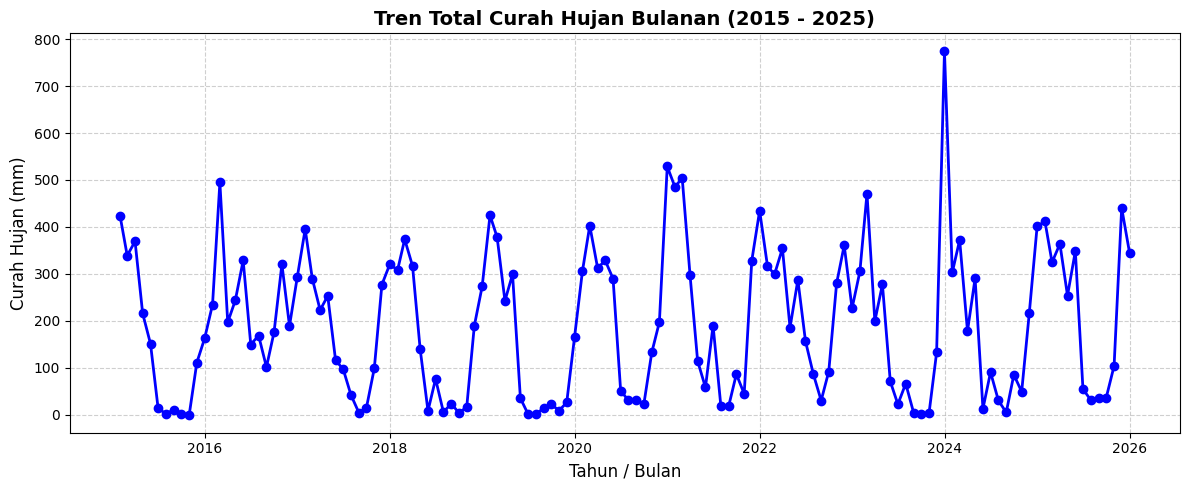

📈 Membuka grafik analisis tren...


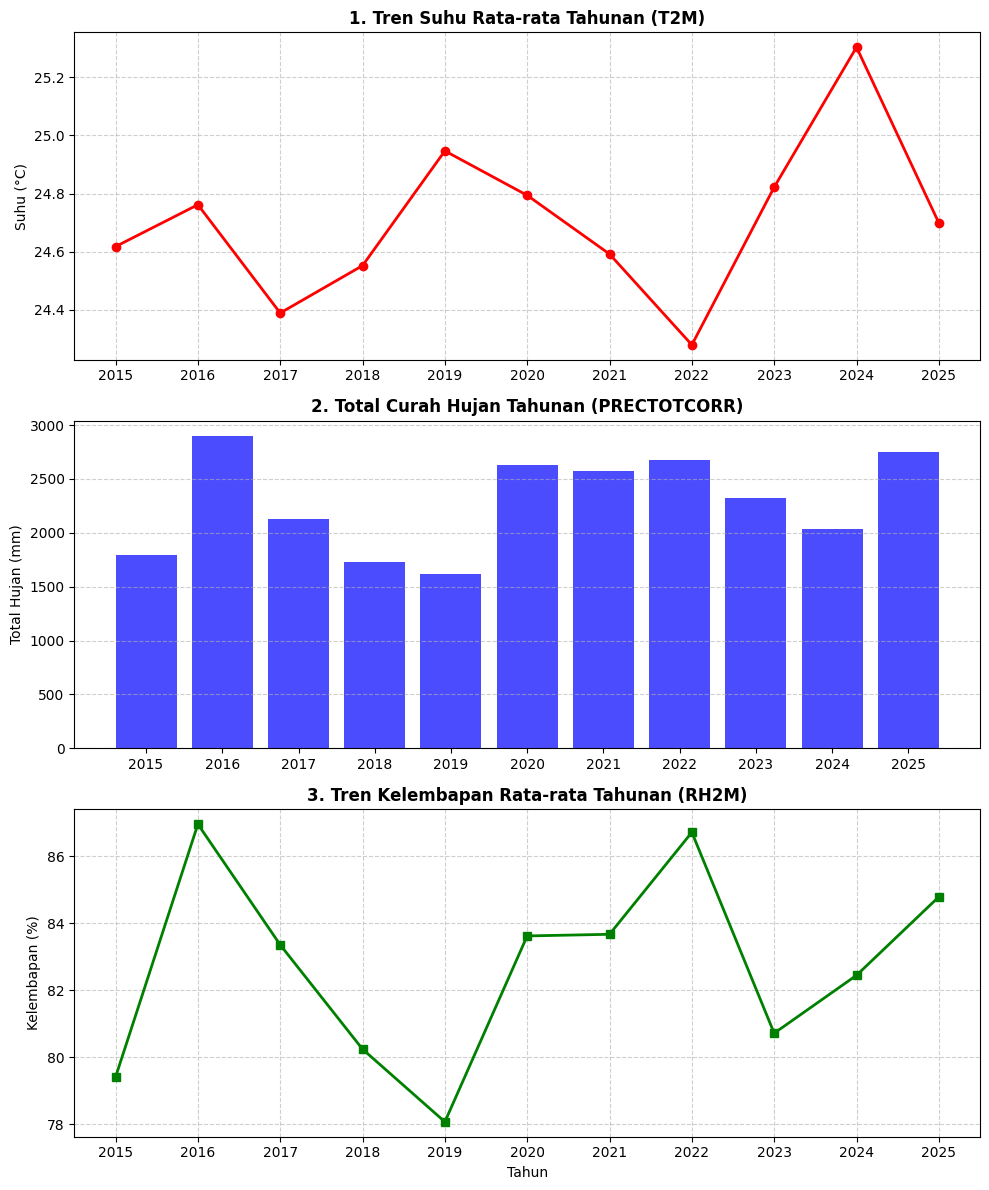

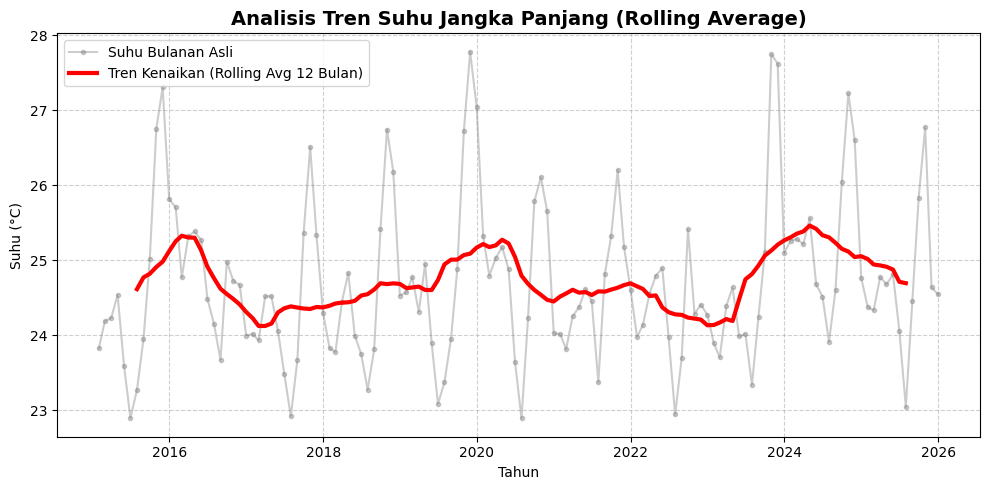


🚨 MEMULAI ANALISIS HUJAN EKSTREM 🚨

1. Jumlah Hari Hujan Ekstrem (>100mm) per Tahun:
   - Tahun 2023: 2 kejadian

2. Top 10 Hari Hujan Paling Ekstrem (All-Time Record):
            PRECTOTCORR    T2M   RH2M
Date                                 
2023-12-01       281.24  25.53  89.31
2023-12-04       205.51  25.03  88.67
2025-04-01        88.58  24.39  84.85
2019-02-02        78.60  24.30  90.32
2023-12-05        78.58  24.76  89.72
2024-04-05        76.60  25.89  87.92
2019-01-17        67.92  24.16  90.71
2020-12-05        62.01  24.22  88.37
2016-10-02        61.91  23.71  93.31
2016-05-30        59.02  24.59  92.39

3. Bulan Paling Rawan Hujan Lebat/Ekstrem:
   - Des: 7 kejadian
   - Feb: 5 kejadian
   - Jan: 3 kejadian
   - Mei: 2 kejadian
   - Apr: 2 kejadian
   - Okt: 2 kejadian
   - Mar: 1 kejadian
   - Sep: 1 kejadian
   - Nov: 1 kejadian

📊 Membuka grafik tren curah hujan ekstrem...


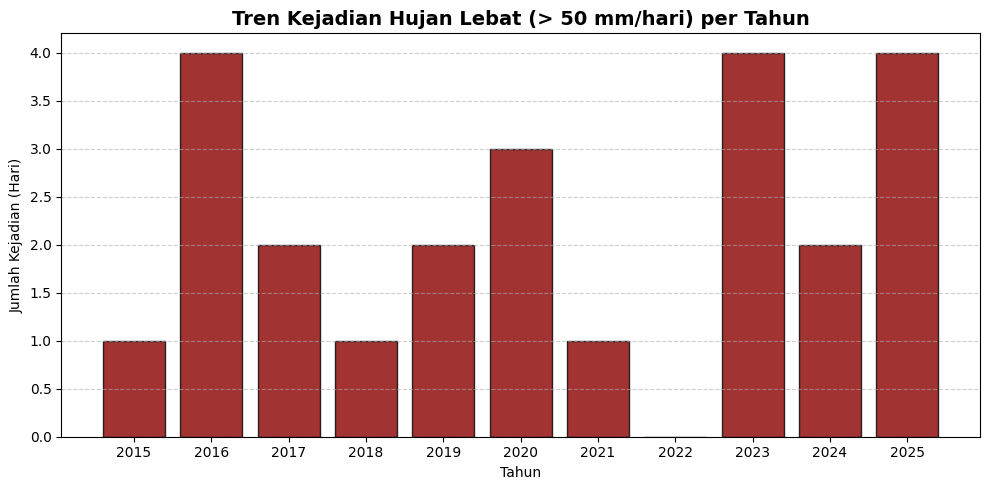


🌤️ MEMULAI ANALISIS POLA MUSIM (KLIMATOLOGI) 🌤️
📊 Membuka grafik pola musim...


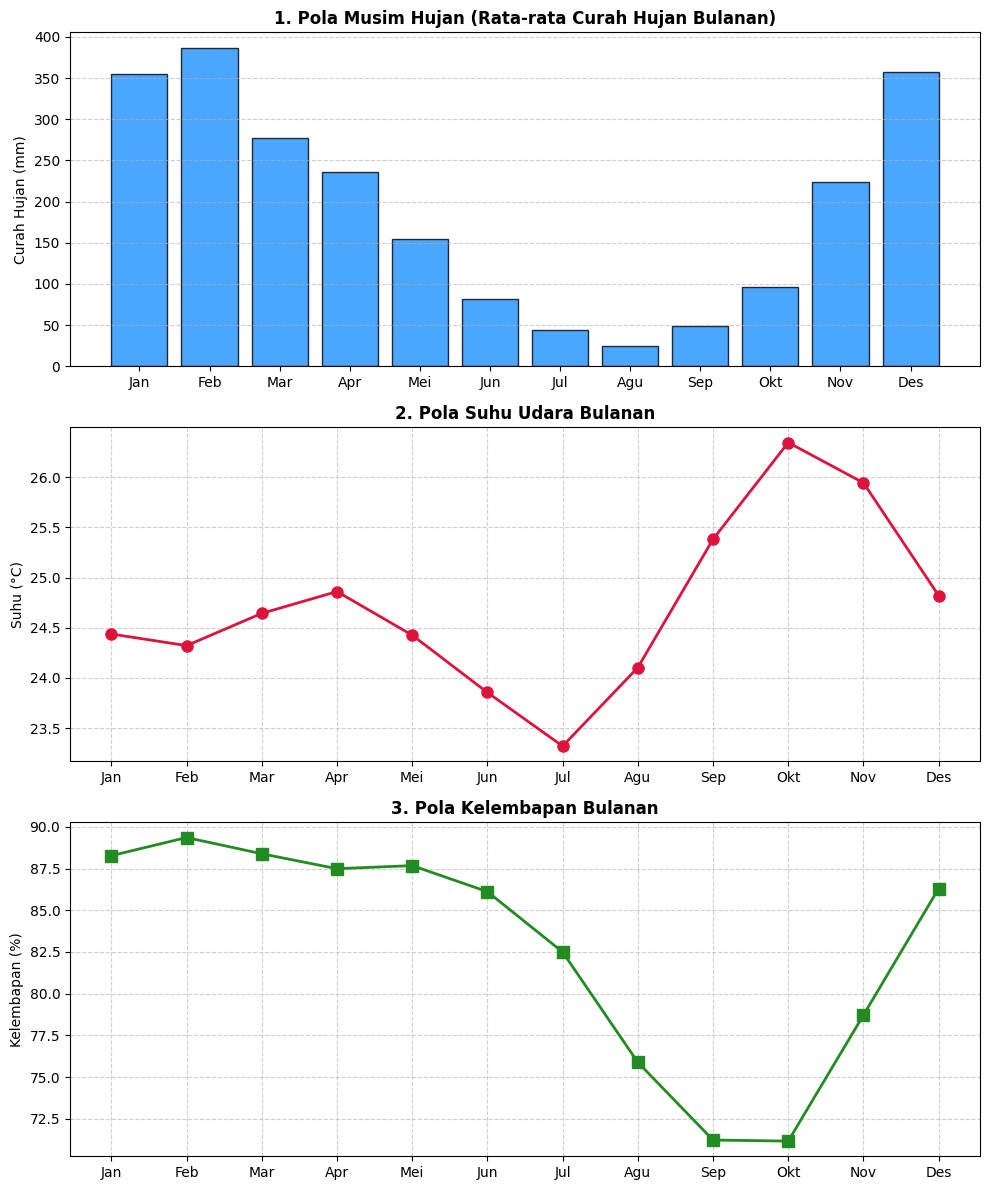

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("climatology_daily_2015-2025.csv", index_col="Date", parse_dates=True)

print("--- DATA BERHASIL DI-LOAD ---")
print(df.head())

df['Hari_Hujan'] = df['PRECTOTCORR'] >= 1.0

print("\n=============================================")
print("  PROFIL IKLIM TAHUNAN (2015 - 2025)")
print("=============================================")

profil_tahunan = df.groupby(df.index.year).agg(
    Rata_Suhu_Tahunan=('T2M', 'mean'),
    Total_Hujan_Tahunan=('PRECTOTCORR', 'sum'),
    Rata_Kelembapan_Tahunan=('RH2M', 'mean'),
    Total_Hari_Hujan=('Hari_Hujan', 'sum')
)

print(profil_tahunan.round(2).to_string())

print("\n=============================================")
print("  REKOR BULANAN EKSTREM (ALL-TIME)")
print("=============================================")

df_bulanan_mean = df.resample('ME').mean()
df_bulanan_sum = df.resample('ME').sum()

idx_panas = df_bulanan_mean['T2M'].idxmax()
suhu_panas = df_bulanan_mean['T2M'].max()

idx_basah = df_bulanan_sum['PRECTOTCORR'].idxmax()
hujan_basah = df_bulanan_sum['PRECTOTCORR'].max()

idx_kering = df_bulanan_sum['PRECTOTCORR'].idxmin()
hujan_kering = df_bulanan_sum['PRECTOTCORR'].min()

print(f"🔥 Bulan Terpanas : {idx_panas.strftime('%B %Y')} (Rata-rata Suhu: {suhu_panas:.2f}°C)")
print(f"🌧️ Bulan Terbasah : {idx_basah.strftime('%B %Y')} (Total Hujan: {hujan_basah:.2f} mm)")
print(f"🌵 Bulan Terkering: {idx_kering.strftime('%B %Y')} (Total Hujan: {hujan_kering:.2f} mm)")

print("\n=============================================")
print("  RATA-RATA JUMLAH HARI HUJAN PER BULAN")
print("=============================================")

hari_hujan_per_bulan = df.groupby([df.index.year, df.index.month])['Hari_Hujan'].sum()
rata_hari_hujan = hari_hujan_per_bulan.groupby(level=1).mean()
nama_bulan = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
              'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']

for i, bln in enumerate(nama_bulan):
    print(f"- {bln.ljust(10)}: Rata-rata {rata_hari_hujan.iloc[i]:.1f} Hari Hujan")

print("⚙️ Memproses data bulanan dan tahunan...")

df_monthly = pd.DataFrame()
df_monthly["T2M_mean"] = df["T2M"].resample("ME").mean()
df_monthly["RH2M_mean"] = df["RH2M"].resample("ME").mean()
df_monthly["RAIN_total"] = df["PRECTOTCORR"].resample("ME").sum()
df_monthly["RAIN_days"] = (df["PRECTOTCORR"] >= 1).resample("ME").sum()

df_yearly = pd.DataFrame()
df_yearly["T2M_mean"] = df["T2M"].resample("YE").mean()
df_yearly["RH2M_mean"] = df["RH2M"].resample("YE").mean()
df_yearly["RAIN_total"] = df["PRECTOTCORR"].resample("YE").sum()
df_yearly["RAIN_days"] = (df["PRECTOTCORR"] >= 1).resample("YE").sum()

path_monthly = "hasil_bulanan_2015-2025.csv"
path_yearly = "hasil_tahunan_2015-2025.csv"

df_monthly.to_csv(path_monthly)
df_yearly.to_csv(path_yearly)

print("\n✅ SUKSES! File baru berhasil dibuat di foldermu:")
print(f"👉 {path_monthly}")
print(f"👉 {path_yearly}")

plt.figure(figsize=(12, 5))
plt.plot(df_monthly.index, df_monthly["RAIN_total"], color="blue", marker="o", linestyle="-", linewidth=2)
plt.title("Tren Total Curah Hujan Bulanan (2015 - 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Tahun / Bulan", fontsize=12)
plt.ylabel("Curah Hujan (mm)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
print("📊 Membuka grafik curah hujan...")
plt.show()

print("📈 Membuka grafik analisis tren...")
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(df_yearly.index.year, df_yearly["T2M_mean"], marker='o', color='red', linewidth=2)
axes[0].set_title("1. Tren Suhu Rata-rata Tahunan (T2M)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Suhu (°C)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks(df_yearly.index.year)

axes[1].bar(df_yearly.index.year, df_yearly["RAIN_total"], color='blue', alpha=0.7)
axes[1].set_title("2. Total Curah Hujan Tahunan (PRECTOTCORR)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Total Hujan (mm)")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)
axes[1].set_xticks(df_yearly.index.year)

axes[2].plot(df_yearly.index.year, df_yearly["RH2M_mean"], marker='s', color='green', linewidth=2)
axes[2].set_title("3. Tren Kelembapan Rata-rata Tahunan (RH2M)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Kelembapan (%)")
axes[2].set_xlabel("Tahun")
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].set_xticks(df_yearly.index.year)

plt.tight_layout()
plt.show()

df_monthly['T2M_rolling_12'] = df_monthly['T2M_mean'].rolling(window=12, center=True).mean()

plt.figure(figsize=(10, 5))
plt.plot(df_monthly.index, df_monthly['T2M_mean'], label='Suhu Bulanan Asli', color='gray', alpha=0.4, marker='.')
plt.plot(df_monthly.index, df_monthly['T2M_rolling_12'], label='Tren Kenaikan (Rolling Avg 12 Bulan)', color='red', linewidth=3)
plt.title("Analisis Tren Suhu Jangka Panjang (Rolling Average)", fontsize=14, fontweight='bold')
plt.xlabel("Tahun")
plt.ylabel("Suhu (°C)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n🚨 MEMULAI ANALISIS HUJAN EKSTREM 🚨")
hujan_lebat = df[df["PRECTOTCORR"] > 50]
hujan_ekstrem = df[df["PRECTOTCORR"] > 100]

ekstrem_per_tahun = hujan_ekstrem.resample("YE").size()
print("\n1. Jumlah Hari Hujan Ekstrem (>100mm) per Tahun:")
for tahun, jumlah in ekstrem_per_tahun.items():
    print(f"   - Tahun {tahun.year}: {jumlah} kejadian")

top_10_hujan = df.nlargest(10, "PRECTOTCORR")[["PRECTOTCORR", "T2M", "RH2M"]]
print("\n2. Top 10 Hari Hujan Paling Ekstrem (All-Time Record):")
print(top_10_hujan.to_string())

bulan_rawan = hujan_lebat.groupby(hujan_lebat.index.month).size().sort_values(ascending=False)
nama_bulan_short = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

print("\n3. Bulan Paling Rawan Hujan Lebat/Ekstrem:")
for bulan_angka, jumlah in bulan_rawan.items():
    print(f"   - {nama_bulan_short[bulan_angka-1].ljust(3)}: {jumlah} kejadian")

plt.figure(figsize=(10, 5))
lebat_per_tahun = hujan_lebat.resample("YE").size()
plt.bar(lebat_per_tahun.index.year, lebat_per_tahun.values, color='darkred', alpha=0.8, edgecolor='black')
plt.title("Tren Kejadian Hujan Lebat (> 50 mm/hari) per Tahun", fontsize=14, fontweight='bold')
plt.xlabel("Tahun")
plt.ylabel("Jumlah Kejadian (Hari)")
plt.xticks(lebat_per_tahun.index.year)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
print("\n📊 Membuka grafik tren curah hujan ekstrem...")
plt.show()

print("\n🌤️ MEMULAI ANALISIS POLA MUSIM (KLIMATOLOGI) 🌤️")
klimatologi_bulanan = df_monthly.groupby(df_monthly.index.month).mean()

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].bar(nama_bulan_short, klimatologi_bulanan["RAIN_total"], color='dodgerblue', edgecolor='black', alpha=0.8)
axes[0].set_title("1. Pola Musim Hujan (Rata-rata Curah Hujan Bulanan)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Curah Hujan (mm)")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

axes[1].plot(nama_bulan_short, klimatologi_bulanan["T2M_mean"], marker='o', color='crimson', linewidth=2, markersize=8)
axes[1].set_title("2. Pola Suhu Udara Bulanan", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Suhu (°C)")
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(nama_bulan_short, klimatologi_bulanan["RH2M_mean"], marker='s', color='forestgreen', linewidth=2, markersize=8)
axes[2].set_title("3. Pola Kelembapan Bulanan", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Kelembapan (%)")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
print("📊 Membuka grafik pola musim...")
plt.show()